In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [2]:
df=pd.read_csv("D:\\Artifical Intelligence\\Datasets\\student_mental_health_burnout.csv")
df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


# Section 1: Data Understanding

In [3]:
# In this step we check the shape of the data 
df.shape

(150000, 20)

In [4]:
# This checks the unique values of students in the data set
df['student_id'].unique()

array([100001, 100002, 100003, ..., 249998, 249999, 250000],
      shape=(150000,))

In [5]:
# This checks the null valuea in each column
df.isnull().sum()

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64

In [6]:
# And we can also check the missing values acroos the data set by this
df.isnull().sum().sum()

np.int64(0)

In [7]:
# To check the data type of the features of data set
df.dtypes

student_id                   int64
age                          int64
gender                         str
course                         str
year                           str
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
stress_level                   str
anxiety_score                int64
depression_score             int64
academic_pressure_score      int64
financial_stress_score       int64
social_support_score         int64
physical_activity_hours    float64
sleep_quality                  str
attendance_percentage      float64
cgpa                       float64
internet_quality               str
burnout_level                  str
dtype: object

In [8]:
#To  Calculate the mean, median, and standard deviation for cgpa, daily_study_hours, and
# screen_time_hours

cols = ['cgpa','daily_study_hours','screen_time_hours']

print("Mean:\n", df[cols].mean())
print("Median:\n", df[cols].median())
print("Std Dev:\n", df[cols].std())

Mean:
 cgpa                 6.997389
daily_study_hours    5.507869
screen_time_hours    6.502819
dtype: float64
Median:
 cgpa                 6.99
daily_study_hours    5.50
screen_time_hours    6.50
dtype: float64
Std Dev:
 cgpa                 1.732180
daily_study_hours    2.595592
screen_time_hours    3.178948
dtype: float64


In [9]:
#In this step we calculate which gender has the highest average anxiety_score
gender_anxiety=df.groupby("gender")["anxiety_score"].mean()
print(gender_anxiety)

print("Highest:", gender_anxiety.idxmax(), "=", gender_anxiety.max())

gender
Female    5.488237
Male      5.502862
Other     5.490629
Name: anxiety_score, dtype: float64
Highest: Male = 5.502862060683692


In [10]:
# Here we List all unique course values and calculate the proportion of students in each course.

print(df['course'].unique())
print(df["course"].value_counts(normalize=True))


<StringArray>
['BTech', 'BCA', 'BSc', 'MBA', 'MCA', 'BBA']
Length: 6, dtype: str
course
MBA      0.168207
BBA      0.167353
BCA      0.166487
MCA      0.166333
BSc      0.165960
BTech    0.165660
Name: proportion, dtype: float64


In [11]:
# cgpa vs sleep_quantity
print(df.groupby('sleep_quality')['cgpa'].mean())

sleep_quality
Average    6.991159
Good       7.013745
Poor       6.987189
Name: cgpa, dtype: float64


In [12]:
# Here we perform what is the distribution of year of study? How many students are in each academic
# year
print(df['year'].value_counts())

year
1st    37680
4th    37622
3rd    37422
2nd    37276
Name: count, dtype: int64


In [13]:
corr=df['daily_study_hours'].corr(df['cgpa'])
corr

np.float64(-0.005449724676499281)

In [14]:
stress_counts = df['stress_level'].value_counts()
stress_percent = df['stress_level'].value_counts(normalize=True) * 100

print(stress_counts)
print(stress_percent)

stress_level
High      50295
Medium    50090
Low       49615
Name: count, dtype: int64
stress_level
High      33.530000
Medium    33.393333
Low       33.076667
Name: proportion, dtype: float64


# Section 2: Data Cleaning

In [15]:
# Check each rows if there is only one value in the row 
rows_with_nan = df.isnull().any(axis=1).sum()
print("Rows with at least one NaN:", rows_with_nan)

Rows with at least one NaN: 0


In [16]:
# Check if all value in the row are nan

nan_rows = df.isnull().all(axis=1).sum()
print(nan_rows)

0


In [17]:
# Total duplicate values in the data set
duplicates = df.duplicated().sum()

print("Total duplicate rows:", duplicates)


Total duplicate rows: 0


In [18]:
# now we are going to check the outliers in the data set
# so at first we separate the int and float columns
num_col=df.select_dtypes(include=["int","float"]).columns 

In [19]:
df[num_col].dtypes

student_id                   int64
age                          int64
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
anxiety_score                int64
depression_score             int64
academic_pressure_score      int64
financial_stress_score       int64
social_support_score         int64
physical_activity_hours    float64
attendance_percentage      float64
cgpa                       float64
dtype: object

In [20]:
# now in this step we detect the outliers
# Sirf numerical columns lo
for col in num_col:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, "-> Outliers:", len(outliers))

student_id -> Outliers: 0
age -> Outliers: 0
daily_study_hours -> Outliers: 0
daily_sleep_hours -> Outliers: 0
screen_time_hours -> Outliers: 0
anxiety_score -> Outliers: 0
depression_score -> Outliers: 0
academic_pressure_score -> Outliers: 0
financial_stress_score -> Outliers: 0
social_support_score -> Outliers: 0
physical_activity_hours -> Outliers: 0
attendance_percentage -> Outliers: 0
cgpa -> Outliers: 0


In [21]:
#  This result shows that there or no outlier in the data set 

In [22]:
# NOw in this step we are converting the categorical columns in numerical format 
cat_col=df.select_dtypes(include=['str']).columns

In [23]:
df[cat_col].dtypes

gender              str
course              str
year                str
stress_level        str
sleep_quality       str
internet_quality    str
burnout_level       str
dtype: object

In [24]:
df.head(10)

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low
5,100006,19,Male,BSc,3rd,8.2,4.8,4.1,High,8,4,9,8,2,1.9,Poor,51.7,6.82,Average,Low
6,100007,23,Other,BSc,2nd,3.0,8.0,7.8,Low,5,9,9,2,6,0.5,Average,77.1,5.36,Average,Low
7,100008,24,Male,BTech,2nd,4.6,6.3,7.6,Medium,5,10,3,10,6,0.6,Poor,59.3,5.91,Average,Low
8,100009,21,Male,MBA,3rd,8.1,5.4,1.3,Low,1,1,7,2,1,1.7,Average,70.6,7.23,Average,Low
9,100010,20,Male,BCA,3rd,9.7,7.0,11.5,Medium,4,2,4,3,7,1.3,Poor,65.0,6.26,Poor,Medium


In [25]:
course=df['course'].value_counts().nlargest(3).index
print(course)

Index(['MBA', 'BBA', 'BCA'], dtype='str', name='course')


In [26]:
df['course']=df['course'].apply(lambda x: x if x in course else "Others")
print(df['course'])

0         Others
1         Others
2            BCA
3         Others
4         Others
           ...  
149995    Others
149996       BCA
149997    Others
149998    Others
149999    Others
Name: course, Length: 150000, dtype: str


In [27]:
df=pd.get_dummies(df,columns=['gender','course'])

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['stress_level'] = le.fit_transform(df['stress_level'])
df['sleep_quality'] = le.fit_transform(df['sleep_quality'])
df['internet_quality'] = le.fit_transform(df['internet_quality'])
df['burnout_level'] = le.fit_transform(df['burnout_level'])

In [64]:
sleep_map = {'Poor':0, 'Average':1, 'Good':2}
stress_map = {'Low':0, 'Medium':1, 'High':2}

df['sleep_quality'] = df['sleep_quality'].map(sleep_map)
df['stress_level'] = df['stress_level'].map(stress_map)

In [29]:
df.shape

(150000, 25)

In [30]:
df['burnout_binary']=(df['burnout_level'] == 0).astype(int)

In [31]:
df.head(10)

,student_id,age,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,...,internet_quality,burnout_level,gender_Female,gender_Male,gender_Other,course_BBA,course_BCA,course_MBA,course_Others,burnout_binary
0,100001,23,1st,4.3,6.8,6.1,0,10,3,4,...,1,0,False,True,False,False,False,False,True,1
1,100002,20,3rd,1.4,4.7,3.0,0,2,10,8,...,2,1,False,True,False,False,False,False,True,0
2,100003,24,4th,3.7,4.8,1.5,1,2,7,8,...,1,0,True,False,False,False,True,False,False,1
3,100004,21,4th,1.6,6.7,7.0,0,3,3,4,...,1,0,False,True,False,False,False,False,True,1
4,100005,23,4th,2.0,6.7,5.4,0,7,7,6,...,1,1,False,False,True,False,False,False,True,0
5,100006,19,3rd,8.2,4.8,4.1,0,8,4,9,...,0,1,False,True,False,False,False,False,True,0
6,100007,23,2nd,3.0,8.0,7.8,1,5,9,9,...,0,1,False,False,True,False,False,False,True,0
7,100008,24,2nd,4.6,6.3,7.6,2,5,10,3,...,0,1,False,True,False,False,False,False,True,0
8,100009,21,3rd,8.1,5.4,1.3,1,1,1,7,...,0,1,False,True,False,False,False,True,False,0
9,100010,20,3rd,9.7,7.0,11.5,2,4,2,4,...,2,2,False,True,False,False,True,False,False,0


In [32]:
df.dtypes

student_id                   int64
age                          int64
year                           str
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
stress_level                 int64
anxiety_score                int64
depression_score             int64
academic_pressure_score      int64
financial_stress_score       int64
social_support_score         int64
physical_activity_hours    float64
sleep_quality                int64
attendance_percentage      float64
cgpa                       float64
internet_quality             int64
burnout_level                int64
gender_Female                 bool
gender_Male                   bool
gender_Other                  bool
course_BBA                    bool
course_BCA                    bool
course_MBA                    bool
course_Others                 bool
burnout_binary               int64
dtype: object

In [33]:
cols = ['gender_Female', 
        'gender_Male',
        'gender_Other', 
        'course_BBA',
        'course_BCA',
        'course_MBA',
        'course_Others' 
        ]

df[cols] = df[cols].astype(int)

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 26 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   year                     150000 non-null  str    
 3   daily_study_hours        150000 non-null  float64
 4   daily_sleep_hours        150000 non-null  float64
 5   screen_time_hours        150000 non-null  float64
 6   stress_level             150000 non-null  int64  
 7   anxiety_score            150000 non-null  int64  
 8   depression_score         150000 non-null  int64  
 9   academic_pressure_score  150000 non-null  int64  
 10  financial_stress_score   150000 non-null  int64  
 11  social_support_score     150000 non-null  int64  
 12  physical_activity_hours  150000 non-null  float64
 13  sleep_quality            150000 non-null  int64  
 14  attendance_perc

In [35]:
df.drop(columns=['student_id'],axis=0,inplace=True)

In [36]:
df['year'].unique()

<StringArray>
['1st', '3rd', '4th', '2nd']
Length: 4, dtype: str

In [37]:
df['year'] = df['year'].astype(str)


In [38]:
# Here we convert the year values 1st to simple number format 1
df['year'] = df['year'].str.replace(r'(st|nd|rd|th)', '', regex=True)

In [39]:
df['year'] = pd.to_numeric(df['year'])


In [40]:
print(df['year'].head())
print(df['year'].dtype)
print(df['year'].unique())

0    1
1    3
2    4
3    4
4    4
Name: year, dtype: int64
int64
[1 3 4 2]


# Section 3: EDA

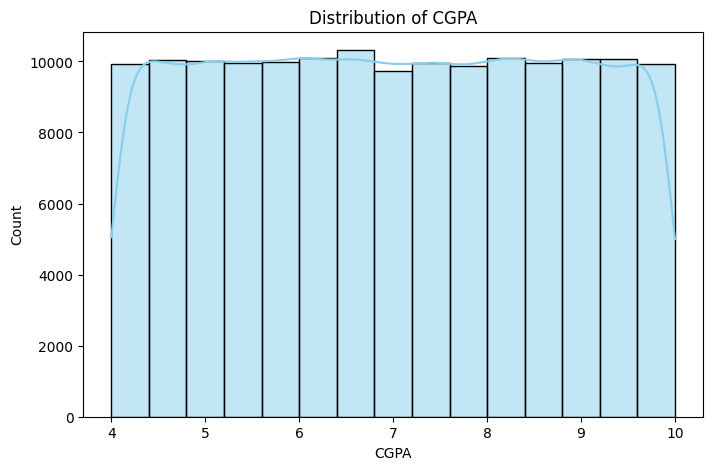

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(df['cgpa'], kde=True, bins=15, color='skyblue')
plt.title("Distribution of CGPA")
plt.xlabel("CGPA")
plt.ylabel("Count")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_4480\4047652573.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stress_level', y='cgpa', data=df, palette='Set2')


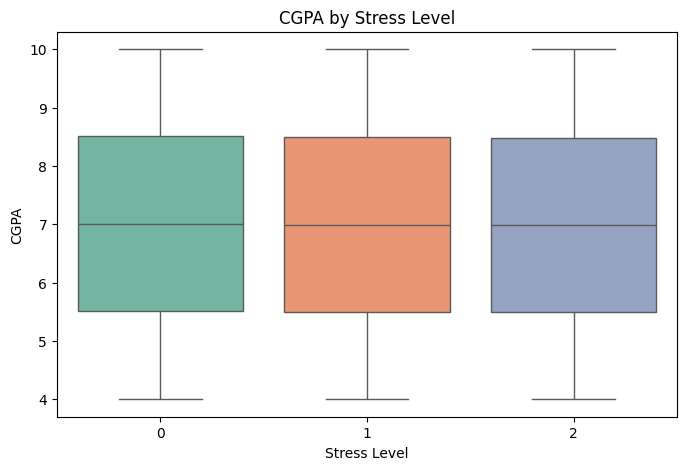

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(x='stress_level', y='cgpa', data=df, palette='Set2')
plt.title("CGPA by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("CGPA")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_4480\3032276245.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gender_Male', y='anxiety_score', data=df, palette='Set1')


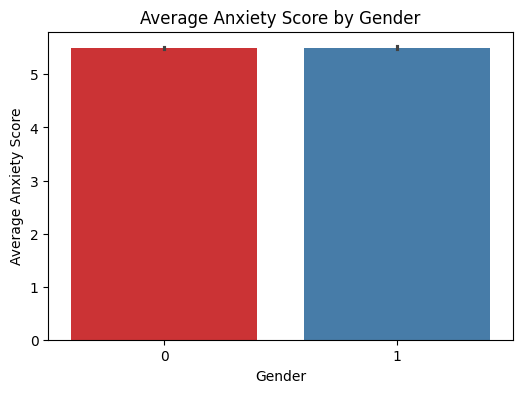

In [43]:
plt.figure(figsize=(6,4))
sns.barplot(x='gender_Male', y='anxiety_score', data=df, palette='Set1')
plt.title("Average Anxiety Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Anxiety Score")
plt.show()


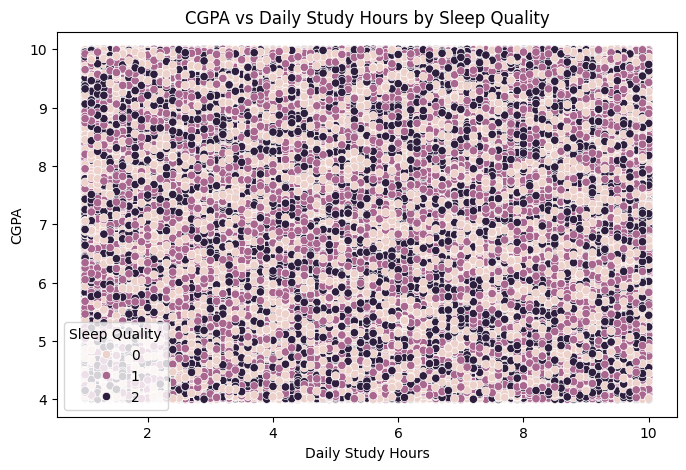

In [44]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='daily_study_hours', y='cgpa', hue='sleep_quality', data=df)
plt.title("CGPA vs Daily Study Hours by Sleep Quality")
plt.xlabel("Daily Study Hours")
plt.ylabel("CGPA")
plt.legend(title='Sleep Quality')
plt.show()


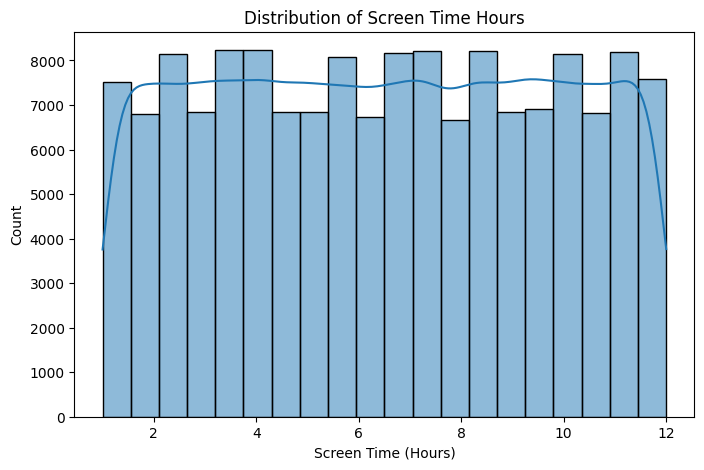

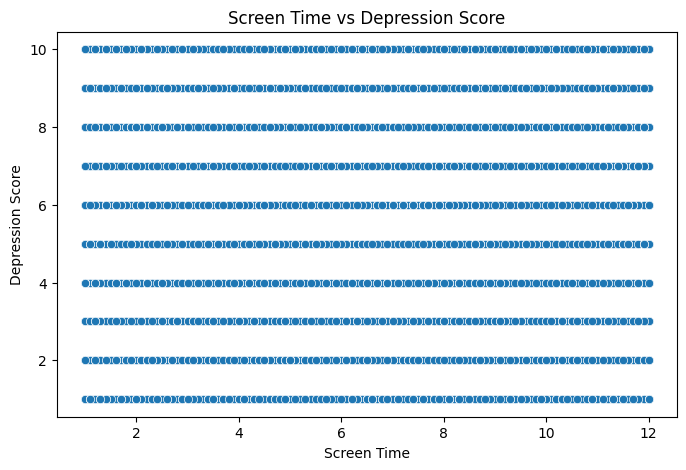

In [45]:
# in this plot we find the distribution of screen time over count

plt.figure(figsize=(8,5))
sns.histplot(df['screen_time_hours'], kde=True, bins=20)
plt.title("Distribution of Screen Time Hours")
plt.xlabel("Screen Time (Hours)")
plt.ylabel("Count")
plt.show()

# in this step we plot the scatter chart to detect the outliers
# Relationship
plt.figure(figsize=(8,5))
sns.scatterplot(x='screen_time_hours', y='depression_score', data=df)
plt.title("Screen Time vs Depression Score")
plt.xlabel("Screen Time")
plt.ylabel("Depression Score")
plt.show()


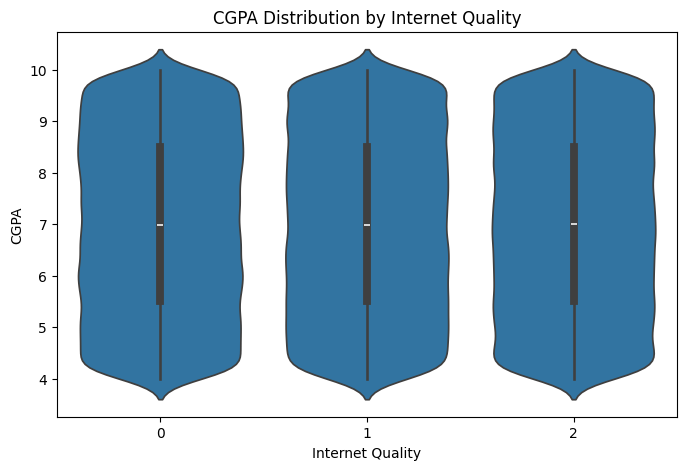

In [46]:
plt.figure(figsize=(8,5))
sns.violinplot(x='internet_quality', y='cgpa', data=df)
plt.title("CGPA Distribution by Internet Quality")
plt.xlabel("Internet Quality")
plt.ylabel("CGPA")
plt.show()


In [47]:
#sns.pairplot(df)

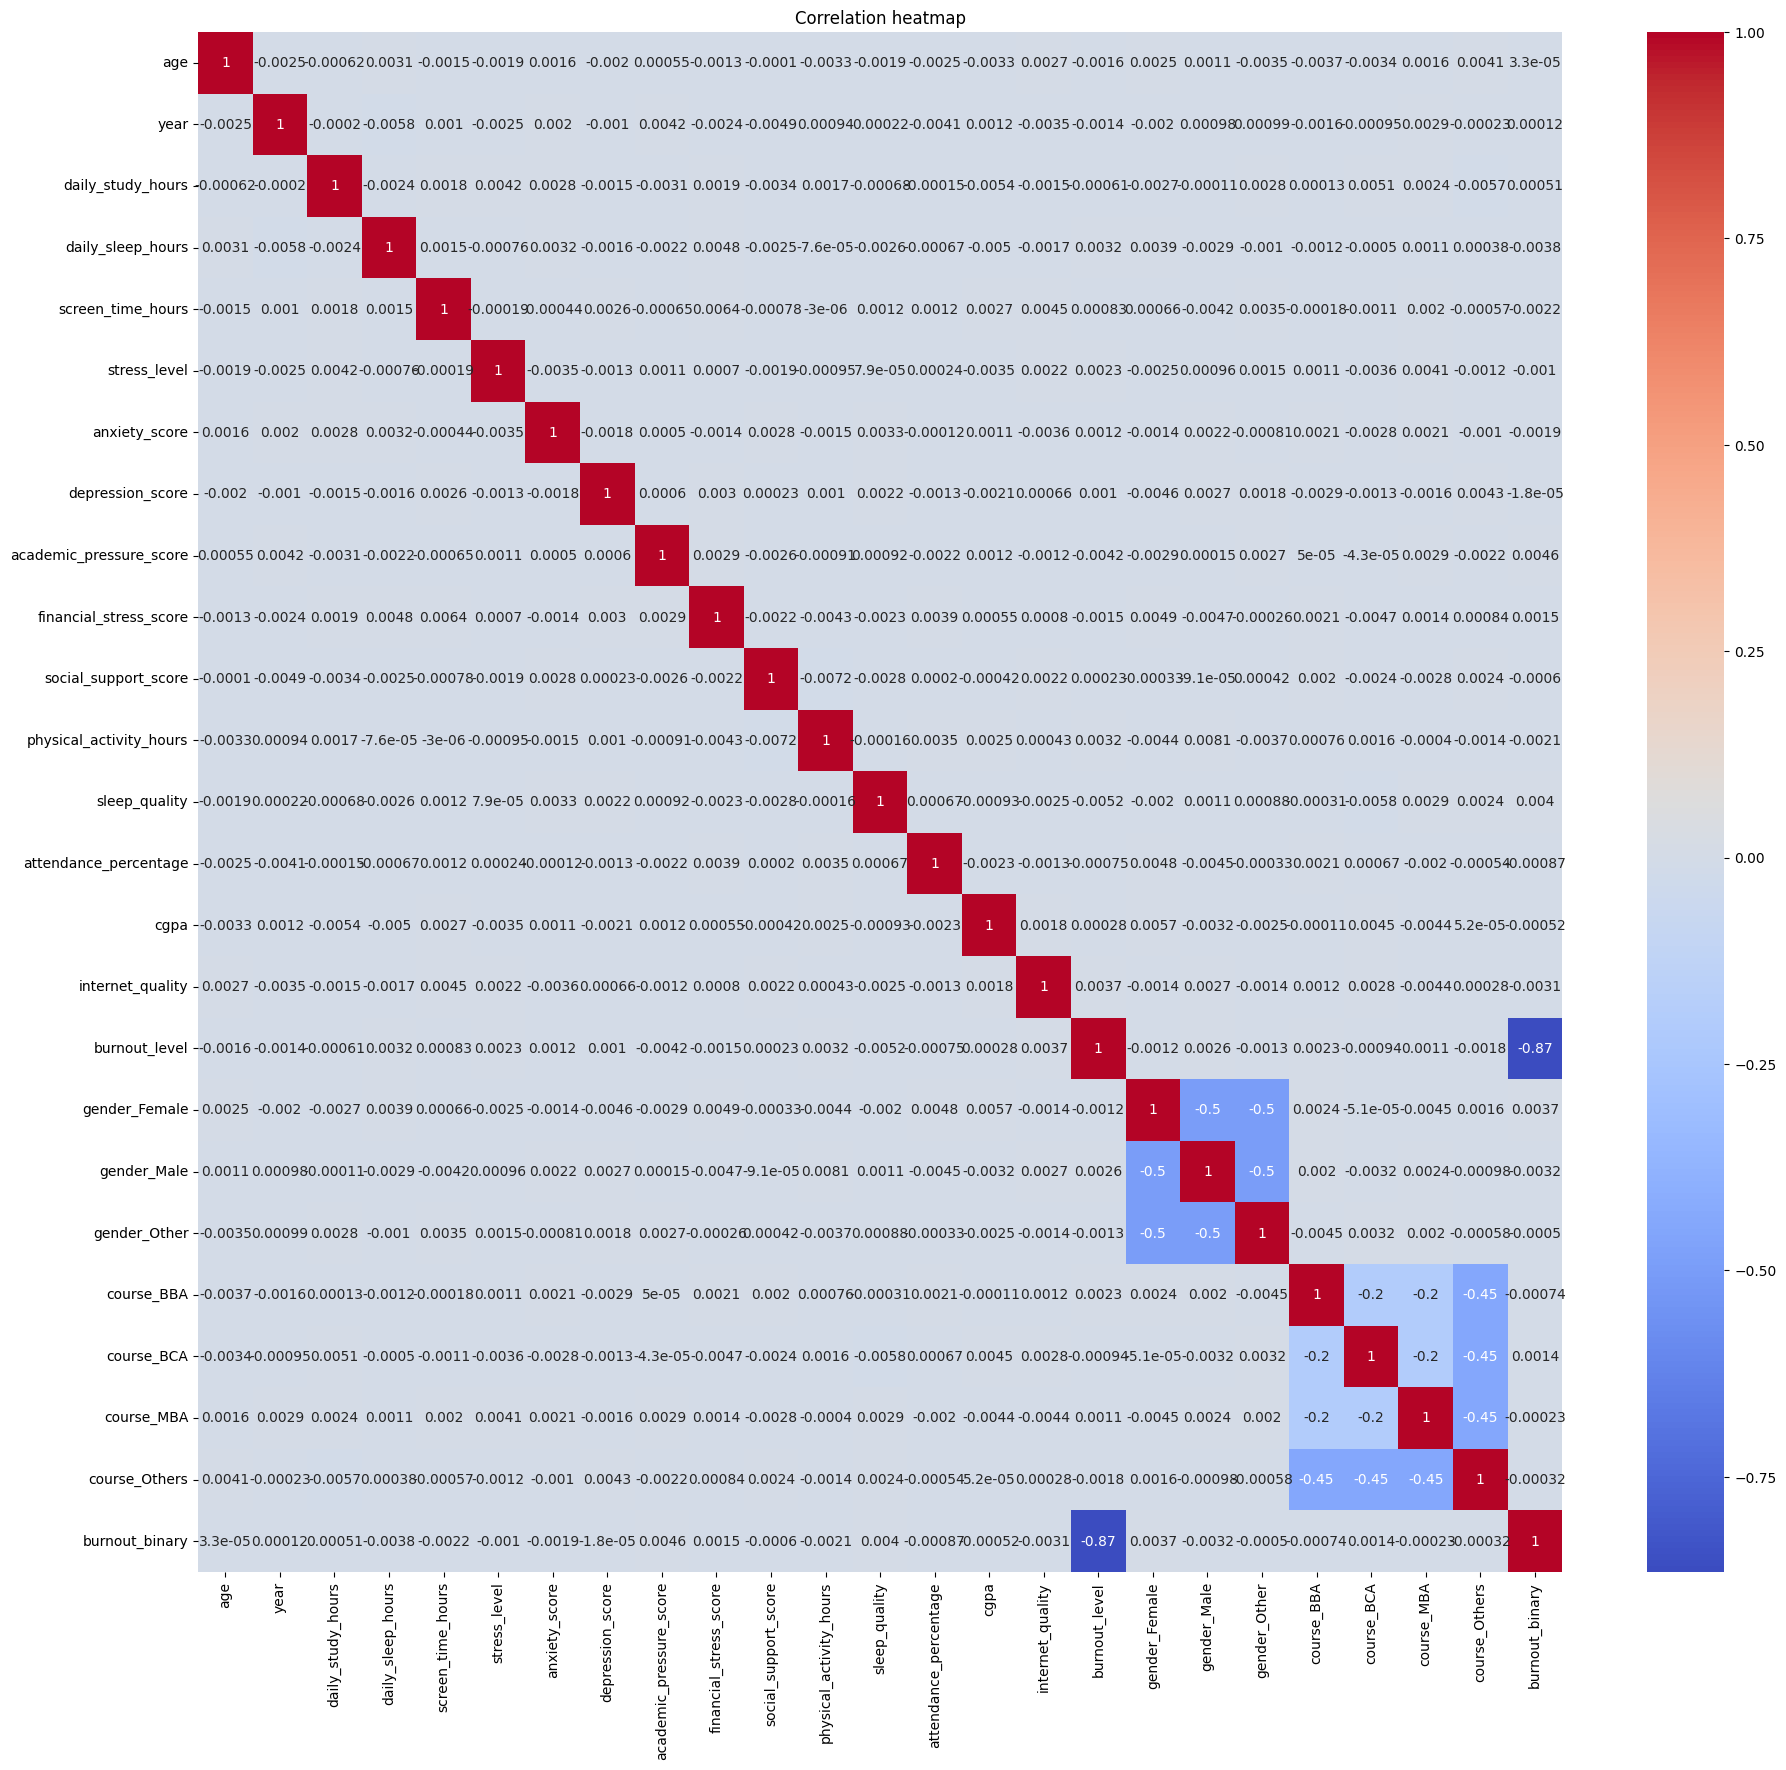

In [48]:
plt.figure(figsize=(22,20))
sns.heatmap(df.corr(),annot=True, cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

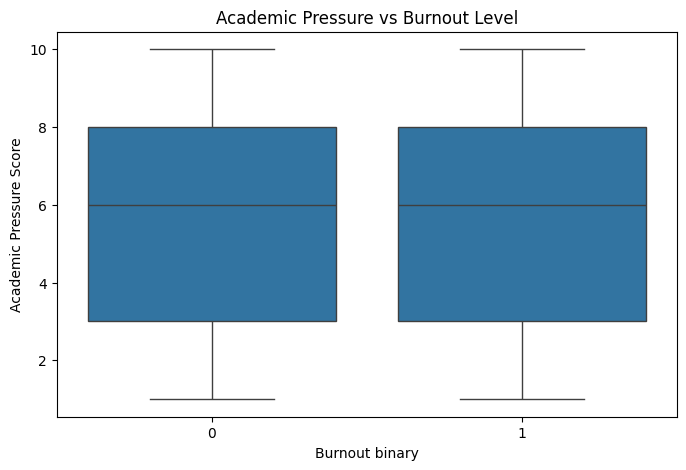

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(x='burnout_binary', y='academic_pressure_score', data=df)

plt.title("Academic Pressure vs Burnout Level")
plt.xlabel("Burnout binary")
plt.ylabel("Academic Pressure Score")
plt.show()


# Section 4: Model Building

In [50]:
X=df[['daily_study_hours','screen_time_hours','anxiety_score']]
y=df['burnout_binary']

In [51]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2,random_state=42)

In [52]:
X_train

,daily_study_hours,screen_time_hours,anxiety_score
104025,6.9,11.2,3
5415,2.6,3.2,10
75612,9.4,10.7,5
138169,6.5,6.3,10
87184,1.8,11.9,5
...,...,...,...
119879,4.3,2.3,10
103694,6.4,1.9,8
131932,2.6,3.5,4
146867,6.6,11.6,6


In [53]:
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

In [54]:
scaler = StandardScaler()
X_poly_scaled= scaler.fit_transform(X_poly)

In [55]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [56]:
y_pred = model.predict(X_test)

# Section 5: Evaluation

In [57]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1:", f1_score(y_test,y_pred))

Accuracy: 0.4999
Precision: 0.33477049615282567
Recall: 0.5036423510627682
F1: 0.40219946607164203


In [58]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))


Confusion Matrix
[[ 9950 10029]
 [ 4974  5047]]


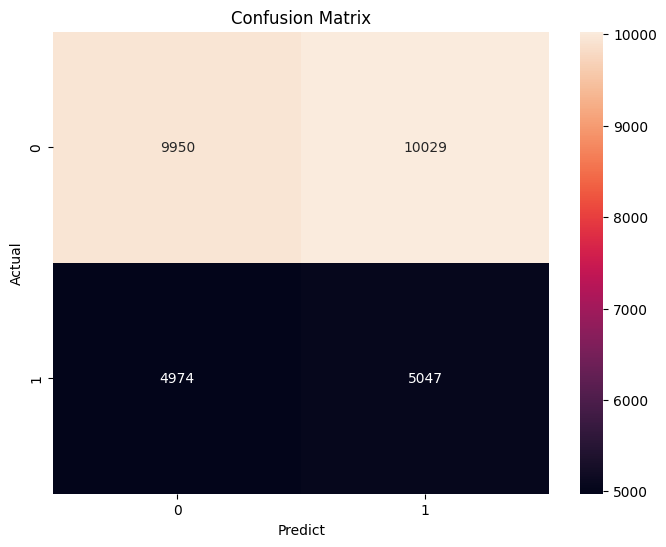

In [59]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='g')
plt.title("Confusion Matrix")
plt.xlabel("Predict")
plt.ylabel("Actual")
plt.show()

In [60]:
roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

0.5015716981825029

In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.50      0.57     19979
           1       0.33      0.50      0.40     10021

    accuracy                           0.50     30000
   macro avg       0.50      0.50      0.49     30000
weighted avg       0.56      0.50      0.51     30000



# Section 6: Interpretation
Coefficients

In [62]:
coeff = pd.DataFrame(model.coef_[0], index=X.columns)
print(coeff.sort_values(by=0))

                          0
screen_time_hours -0.001666
anxiety_score     -0.000624
daily_study_hours -0.000135


Class Imbalance

L1 Regularization

In [ ]:
model_l1 = LogisticRegression(penalty='l1', solver='liblinear')
model_l1.fit(X_train, y_train)

## Final Summary
Key factors influencing burnout include stress, sleep quality, and academic pressure.